<h1 style="text-align: center;"><b>Title</b></h1>
<h3 style="text-align: center;">Spring 2026 Final Project</h3>
<p style="text-align: center;">Matthew Rybak, Jeremy Pak</p>

<br>

Contributions:  
1) Project Idea - Jeremy wanted to do a weather-based project and Matt chose to specifically do UV radiation.  
2) Dataset Curation and Preprocessing - Matt found the dataset, while Jeremy turned it into a CSV file and cleaned up the data to do exploratory data analysis.
3) Data Exploration and Summary Statistics - Matt and Jeremy both did 3 different types of tests, but we decided to use 2 of Matts, and 1 of Jeremy's  
4) ML Algorithm Design/Development  - Matt decided on what algorithm we should be using, and Jeremy set up the model  
5) ML Algorithm Training and Test Data Analysis - Jeremy ran the tests for the algorithm, and Matt provided the ...
6) Visualization, Result Analysis, Conclusion - Jeremy created the Visualiation plot, while matt provided the ...
7) Final Tutorial Report Creation  

<br>

<h3>Project Idea</h3>

Why are you choosing these datasets?  

UV radiation is a prominent cause of skin cancer, damage to eyes and skin, and other health complications. Climate change and global warming weaken the ozone layer which absorbs UV radiation, making UV radiation an ever increasing danger. We would like to determine via this project whether UV radiation will increase in the future.

<h3>Data Curation and Preprocessing</h3>

Github Repository:
https://github.com/mrybak06/cmsc320-project

This dataset can be found at: https://www.temis.nl/uvradiation/UVarchive.php

We chose this dataset because of its large amount of data and that fact that it is organized nicely. The provided legend was especially useful in providing easy-to-understand meaning to the dataset as a whole.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("uv_Gaithersburg_USA_csv.csv", sep=',')
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDEC,UVDECerr,UVDVF,UVDVFerr,UVDVC,UVDVCerr,UVDDF,UVDDFerr,UVDDC,UVDDCerr,CMF,ozone
0,20020701,9.348,0.519,5.263,0.337,-1.0,-1.0,9.831,0.833,-1.0,-1.0,2.785,0.283,-1.0,-1.0,-1.0,318.6
1,20020702,9.821,0.519,5.513,0.336,-1.0,-1.0,10.412,0.832,-1.0,-1.0,3.029,0.283,-1.0,-1.0,-1.0,307.2
2,20020703,8.325,0.518,4.711,0.335,-1.0,-1.0,8.560,0.831,-1.0,-1.0,2.281,0.282,-1.0,-1.0,-1.0,346.4
3,20020704,8.874,0.518,5.001,0.335,-1.0,-1.0,9.234,0.830,-1.0,-1.0,2.547,0.282,-1.0,-1.0,-1.0,330.2
4,20020705,8.847,0.518,4.984,0.335,-1.0,-1.0,9.196,0.829,-1.0,-1.0,2.533,0.282,-1.0,-1.0,-1.0,330.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8664,20260321,4.906,0.354,2.408,0.196,-1.0,-1.0,4.040,0.483,-1.0,-1.0,0.948,0.165,-1.0,-1.0,-1.0,342.6
8665,20260322,5.569,0.357,2.720,0.198,-1.0,-1.0,4.739,0.490,-1.0,-1.0,1.183,0.167,-1.0,-1.0,-1.0,314.0
8666,20260323,5.186,0.361,2.553,0.201,-1.0,-1.0,4.341,0.496,-1.0,-1.0,1.039,0.170,-1.0,-1.0,-1.0,335.5
8667,20260324,4.677,0.365,2.326,0.204,-1.0,-1.0,3.811,0.503,-1.0,-1.0,0.860,0.172,-1.0,-1.0,-1.0,368.1


In [15]:
# Convert YYYYMMDD column into a string, then into a datetime object
df['YYYYMMDD'] = df['YYYYMMDD'].astype(str)
df['YYYYMMDD'] = pd.to_datetime(df['YYYYMMDD'], format='%Y%m%d')
df.replace(-1, pd.NA)

df[['YYYYMMDD', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF', 'UVDVFerr', 'UVDDF',
    'UVDDFerr', 'ozone']].isna().sum().sum()

df = df.drop(['UVDEC', 'UVDECerr', 'UVDVC', 'UVDVCerr', 'UVDDC', 'UVDDCerr', 'CMF',], axis=1, errors="ignore")
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


<h3>Data Exploration and Summary Statistics</h3>

Now that we've gotten the data cleaning out of the way, it's time to make some preliminary hypotheses that will shape the rest of our efforts with this data set.

They are:  
1) Intensity of erythemal UV dose is increased in summer months (June, July, August).  
2) Average intensity of erythemal UV index has increased from 2003 to 2025.  
3) There is a strong positive correlation (>0.66) between UV index and Vitamin D dose.

$H_0$: The summer months do not have a higher erythemal UV dose compared to the other seasons.  
$H_a$: The summer months have a higher erythemal UV dose than the other seasons.

First, since our hypothesis is based on seasonal relationships, we can split our values into their respective months.

### Hypothesis 1

In [16]:
hypo1_df = df

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

hypo1_df['season'] = hypo1_df['YYYYMMDD'].dt.month.apply(get_season)
hypo1_df = hypo1_df.reindex(columns=['YYYYMMDD', 'season', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF',
       'UVDVFerr', 'UVDDF', 'UVDDFerr', 'ozone'])
hypo1_df

,YYYYMMDD,season,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,Summer,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,Summer,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,Summer,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,Summer,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,Summer,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,Spring,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,Spring,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,Spring,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,Spring,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


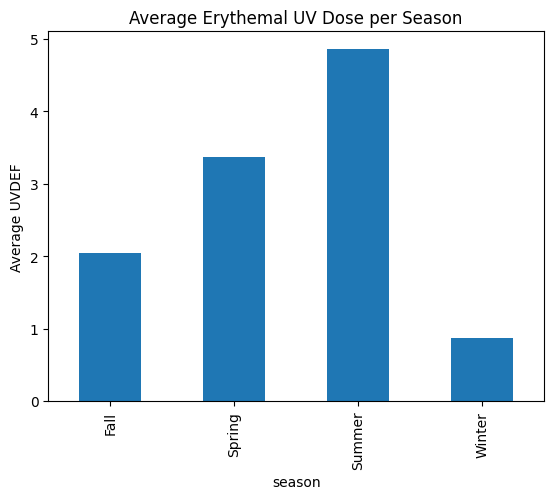

In [17]:
hypo1_df.groupby("season")["UVDEF"].mean().plot(kind="bar")
plt.ylabel("Average UVDEF")
plt.title("Average Erythemal UV Dose per Season")
plt.show()

In [18]:
from scipy import stats

groups = [group["UVDEF"].values for _, group in hypo1_df.groupby("season")]
stats.f_oneway(*groups)

F_onewayResult(statistic=10808.425438483986, pvalue=0.0)

Our p-value is so close to 0 that scipy is simply treating it as 0. Thus, one of our seasons is meaningfully different from the others. Let us observe where the differences lie:

In [19]:
from scipy.stats import tukey_hsd

result = tukey_hsd(*groups).pvalue
display(result)

array([[1.0000000e+00, 4.4408921e-14, 4.4408921e-14, 4.4408921e-14],
       [4.4408921e-14, 1.0000000e+00, 4.4408921e-14, 4.4408921e-14],
       [4.4408921e-14, 4.4408921e-14, 1.0000000e+00, 4.4408921e-14],
       [4.4408921e-14, 4.4408921e-14, 4.4408921e-14, 1.0000000e+00]])

Our processing indicates that not only is summer different from the other seasons, but ALL seasons are meaningfully different from one another. Thus we can reject the null hypothesis and conclude that summer does have a higher erythemal UV dose than the other seasons.

### Hypothesis 2

$H_0$: The average annual UV index has not increased over time.  
$H_a$: The average annual UV index has increased over time.

This time, we want to group our values by year. Since the years 2002 and 2026 are not complete (2002 starts in July and 2026 only goes to March), we will drop those years and only consider 2003-2025.

In [20]:
hypo2_df = df

hypo2_df["year"] = hypo2_df["YYYYMMDD"].dt.year
hypo2_df = hypo2_df[~hypo2_df["year"].isin([2002, 2026])]
hypo2_df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone,season,year
184,2003-01-01,1.430,0.133,0.600,0.062,0.785,0.148,0.152,0.052,322.5,Winter,2003
185,2003-01-02,1.501,0.134,0.627,0.062,0.842,0.149,0.166,0.053,310.1,Winter,2003
186,2003-01-03,1.311,0.135,0.556,0.062,0.685,0.150,0.128,0.053,356.2,Winter,2003
187,2003-01-04,1.382,0.136,0.584,0.063,0.742,0.151,0.141,0.053,340.6,Winter,2003
188,2003-01-05,1.245,0.136,0.533,0.063,0.628,0.152,0.114,0.054,382.0,Winter,2003
...,...,...,...,...,...,...,...,...,...,...,...,...
8580,2025-12-27,1.558,0.131,0.645,0.061,0.891,0.145,0.180,0.051,291.6,Winter,2025
8581,2025-12-28,1.621,0.131,0.669,0.061,0.943,0.146,0.194,0.052,282.3,Winter,2025
8582,2025-12-29,1.609,0.132,0.665,0.061,0.933,0.146,0.191,0.052,285.4,Winter,2025
8583,2025-12-30,1.168,0.132,0.500,0.061,0.570,0.147,0.102,0.052,392.9,Winter,2025


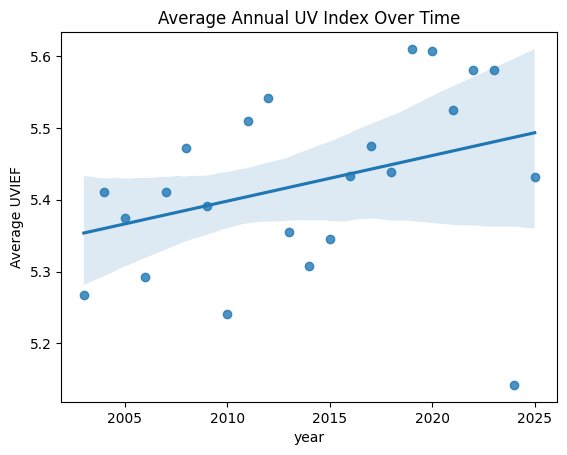

In [21]:
import seaborn as sns

yearly_uv = hypo2_df.groupby("year")["UVIEF"].mean().reset_index()
sns.regplot(x="year", y="UVIEF", data=yearly_uv, ci=95)
plt.title("Average Annual UV Index Over Time")
plt.ylabel("Average UVIEF")
plt.show()

There seems to be a small upward trend, but 2024 appears to be an outlier. We will remove it and do a linear regression test on what remains to see if our slope is significant enough:

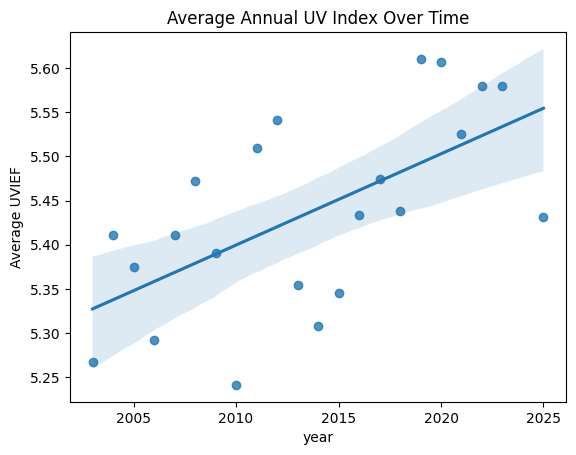

0.001108015031169088

In [22]:
from scipy.stats import linregress

no2024_df = hypo2_df[~hypo2_df["year"].isin([2024])]
yearly_uv_repaired = no2024_df.groupby("year")["UVIEF"].mean().reset_index()
sns.regplot(x="year", y="UVIEF", data=yearly_uv_repaired, ci=95)
plt.title("Average Annual UV Index Over Time")
plt.ylabel("Average UVIEF")
plt.show()
result = linregress(yearly_uv_repaired["year"], yearly_uv_repaired["UVIEF"], alternative="greater")

display(result.pvalue)

Indeed, with a p-value of $0.0011 < 0.05$, we can safely reject the null and conclude that the average annual UV index has increased from 2003 to 2025.

### Hypothesis 3

$H_0$: The correlation between UV index and Vitamin D dose is less than 0.66.  
$H_a$: The correlation between UV index and Vitamin D dose is 0.66 or greater.  

The correlation between UVIEF and UVDVF is: 0.9964


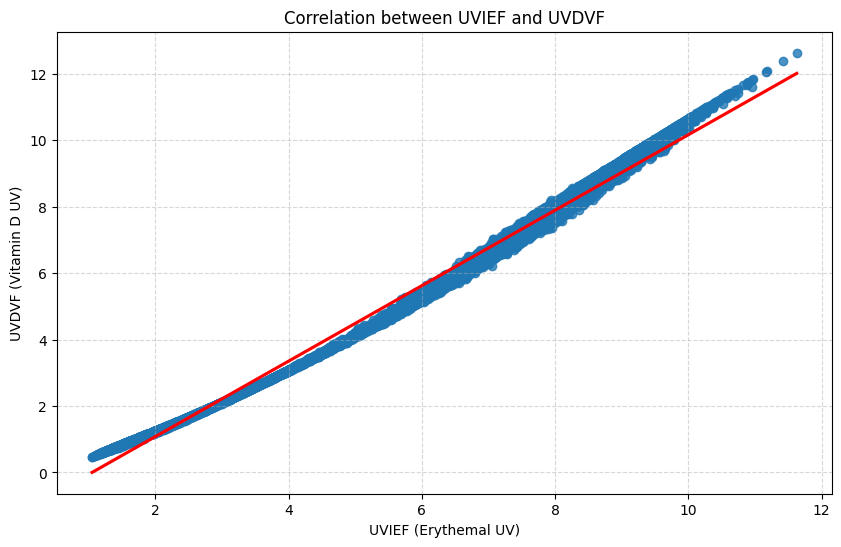

In [23]:
hypo3_df = df
correlation = hypo3_df['UVIEF'].corr(hypo3_df['UVDVF'])

print(f"The correlation between UVIEF and UVDVF is: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='UVIEF', y='UVDVF', data=hypo3_df, line_kws={"color": "red"})

plt.title('Correlation between UVIEF and UVDVF')
plt.xlabel('UVIEF (Erythemal UV)')
plt.ylabel('UVDVF (Vitamin D UV)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Since our Pearson correlation coefficient is 0.9964 > 0.66, we reject our null hypothesis and conclude there is a very strong linear correlation between UV index and Vitamin D dose.

<h3>ML Algorithm Design/Development</h3>

##### Linear Regression Model

In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Use your grouped yearly data
yearly_avg = hypo2_df.groupby("year")["UVIEF"].mean().reset_index()

# 2. Reshape for sklearn (X must be 2D)
X = yearly_avg['year'].values.reshape(-1, 1)
y = yearly_avg['UVIEF'].values

##### Random Forest Regressor + Linear Trend

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. DATA PREPARATION (Excluding 2024 Outlier) ---
# Filter out 2024 along with the partial years 2002 and 2026
df_ml = hypo2_df[~hypo2_df['year'].isin([2002, 2024, 2026])].copy()
df_ml['day_of_year'] = df_ml['YYYYMMDD'].dt.dayofyear

features = ['year', 'day_of_year', 'ozone']
X = df_ml[features]
y = df_ml['UVIEF']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h3>ML Algorithm Training and Test Data Analysis</h3>

##### Linear Regression Training

In [50]:
# Initialize and fit
model = LinearRegression()
model.fit(X, y)

# Extract the trend
slope = model.coef_[0]
intercept = model.intercept_

print(f"Annual rate of UV change: {slope:.5f} units per year")

# Predict for the next 10 years
future_years = np.array(range(2026, 2036)).reshape(-1, 1)
future_preds = model.predict(future_years)

# Display results
for year, uv in zip(range(2026, 2036), future_preds):
    print(f"Predicted UV for {year}: {uv:.4f}")

Annual rate of UV change: 0.00634 units per year
Predicted UV for 2026: 5.4996
Predicted UV for 2027: 5.5059
Predicted UV for 2028: 5.5123
Predicted UV for 2029: 5.5186
Predicted UV for 2030: 5.5249
Predicted UV for 2031: 5.5313
Predicted UV for 2032: 5.5376
Predicted UV for 2033: 5.5440
Predicted UV for 2034: 5.5503
Predicted UV for 2035: 5.5567


##### Random Forest Regressor + Linear Trend Training

In [63]:
# --- 2. HYBRID MODEL TRAINING ---
# Step A: Fit a Linear Model to capture the annual slope (the trend)
lr_trend = LinearRegression()
lr_trend.fit(X_train[['year']], y_train)
trend_slope = lr_trend.coef_[0]

# Step B: Fit the Random Forest to capture seasonal/atmospheric complexity
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

##### Random Forest Regressor + Linear Trend Test Data Analysis

In [64]:
# --- 3. EVALUATION ---
y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest R^2 Accuracy: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Calculated Annual Growth: {trend_slope:.6f} UV units/year")

# --- 4. 10-YEAR HYBRID FORECAST (2026-2035) ---
future_dates = pd.date_range(start='2026-01-01', end='2035-12-31', freq='D')
future_df = pd.DataFrame({'YYYYMMDD': future_dates})
future_df['year'] = future_df['YYYYMMDD'].dt.year
future_df['day_of_year'] = future_df['YYYYMMDD'].dt.dayofyear

# Use historical ozone averages for future dates
avg_ozone = df_ml.groupby('day_of_year')['ozone'].mean()
future_df['ozone'] = future_df['day_of_year'].map(avg_ozone)

Random Forest R^2 Accuracy: 0.9996
Calculated Annual Growth: 0.012623 UV units/year


<h3>Visualization</h3>

##### Linear Regression Visualization

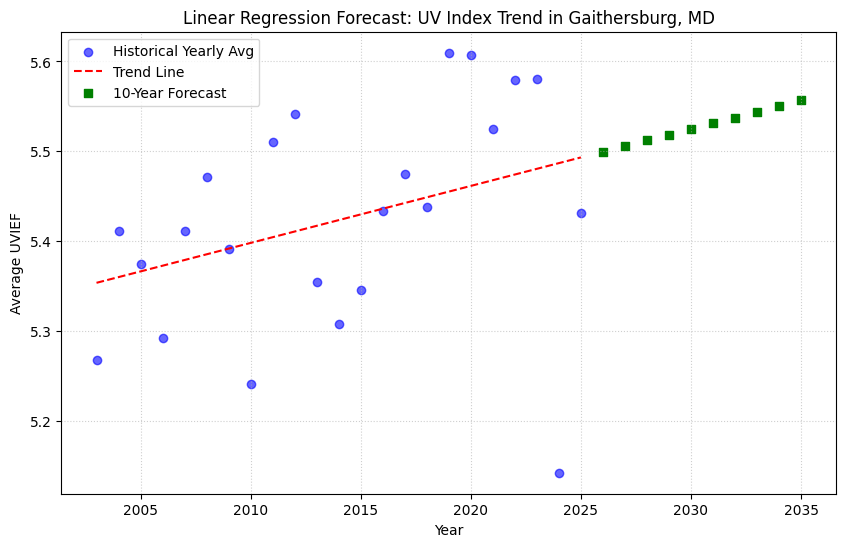

Annual UV Increase: 0.006343 units/year


In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Historical Yearly Avg', alpha=0.6)
plt.plot(X, model.predict(X), color='red', linestyle='--', label='Trend Line')
plt.scatter(future_years, future_preds, color='green', marker='s', label='10-Year Forecast')

plt.title('Linear Regression Forecast: UV Index Trend in Gaithersburg, MD')
plt.xlabel('Year')
plt.ylabel('Average UVIEF')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Print Slope for your Result Analysis
print(f"Annual UV Increase: {model.coef_[0]:.6f} units/year")

##### Random Forest Regressor + Linear Regression Visualization

In [65]:
# HYBRID LOGIC: 
# 1. Get the RF prediction for seasonal patterns
# 2. Add the linear trend growth based on years passed since 2025
base_year = 2025
future_df['seasonal_pattern'] = rf_model.predict(future_df[['year', 'day_of_year', 'ozone']])
future_df['years_ahead'] = future_df['year'] - base_year
future_df['hybrid_prediction'] = future_df['seasonal_pattern'] + (future_df['years_ahead'] * trend_slope)

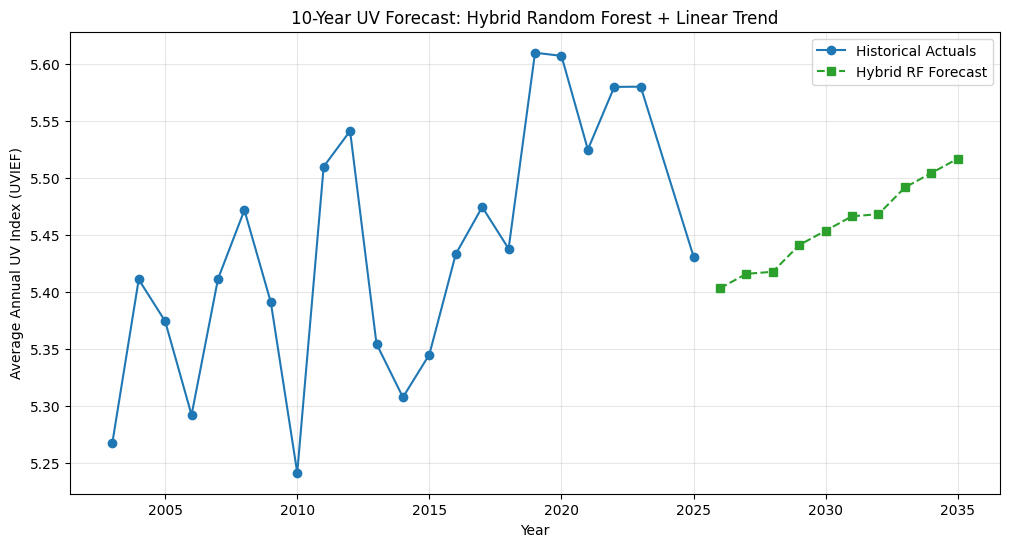

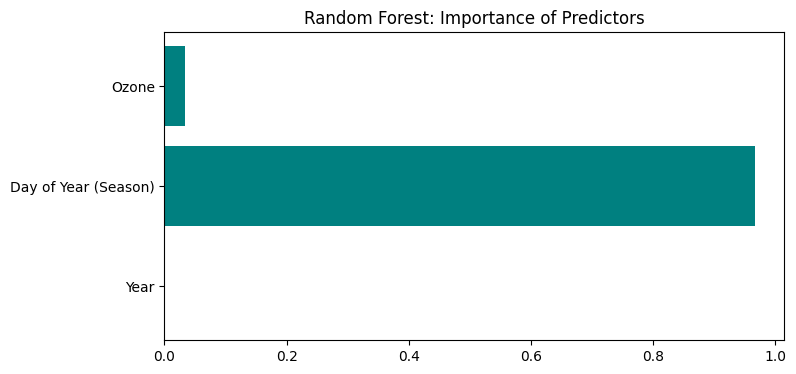

In [66]:
# --- 5. VISUALIZATION ---
historical_yearly = df_ml.groupby('year')['UVIEF'].mean().reset_index()
forecast_yearly = future_df.groupby('year')['hybrid_prediction'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(historical_yearly['year'], historical_yearly['UVIEF'], marker='o', label='Historical Actuals', color='#1f77b4')
plt.plot(forecast_yearly['year'], forecast_yearly['hybrid_prediction'], marker='s', linestyle='--', label='Hybrid RF Forecast', color='#2ca02c')

plt.title('10-Year UV Forecast: Hybrid Random Forest + Linear Trend')
plt.ylabel('Average Annual UV Index (UVIEF)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. FEATURE IMPORTANCE (Excellent for your Result Analysis section)
plt.figure(figsize=(8, 4))
plt.barh(['Year', 'Day of Year (Season)', 'Ozone'], rf_model.feature_importances_, color='teal')
plt.title('Random Forest: Importance of Predictors')
plt.show()

<h3>Result Analysis</h3>

<h3>Conclusion</h3>